# 🧠 Progressive Dataset Revelation for Deep Learning Training
## UCS761 — Deep Learning | Thapar Institute of Engineering & Technology, Patiala


---

| Student | Roll No |
|---|---|
| Samiksha | 102317096 |
| Prabhleen Kaur | 102317143 |
| Arushi Khanna| 102317147 |
| Prachi Jindal | 102317153 |

**Submitted To:** Mr. Sukhpal Singh, Research Associate, Dept. of CSE, TIET

---

## 📋 Abstract

In most deep learning systems, models are trained on the **entire dataset from epoch 1**. This project challenges that assumption by systematically investigating how **data exposure strategy** — the order and pace at which training samples are revealed — affects learning dynamics, convergence speed, and generalization behaviour.

We train and compare **3 architectures** under **3 training strategies** on CIFAR-10:

| Architecture | Type | Key Property |
|---|---|---|
| VGG-11 | Classical deep CNN | No skip connections — most sensitive to data ordering |
| ResNet-18 | Residual network | Skip connections stabilise gradient flow |
| MobileNet-V2 | Lightweight efficient CNN | Depthwise separable — lowest sensitivity to strategy |

| Strategy | Description |
|---|---|
| **Full Dataset** | Baseline — all 50,000 samples from epoch 1 |
| **Progressive Revelation** | 10% → 25% → 50% → 75% → 100% across 5 stages |
| **Curriculum Learning** | Easy samples first (bottom 30%), hard samples last |

> **Total: 9 controlled experiments, 20 epochs each, fixed seed 42 for reproducibility.**

---

## 🔬 Research Questions

1. Does progressive data exposure improve **convergence speed** over full dataset training?
2. Does curriculum learning improve **generalization** (train-val gap) over random ordering?
3. Which architecture is most **sensitive** to the choice of training strategy?

---

## 📦 Dataset

- **CIFAR-10** — 60,000 RGB images, 32×32 pixels, 10 classes
- 50,000 training / 10,000 test — perfectly class-balanced
- Source: [https://www.cs.toronto.edu/~kriz/cifar.html](https://www.cs.toronto.edu/~kriz/cifar.html)

---


## 2. 🔧 Environment Setup — Library Installation & GPU Configuration

### Libraries Used

| Library | Version | Purpose |
|---|---|---|
| `torch` | 2.x | Core deep learning framework — model definition, training, autograd |
| `torchvision` | 0.x | CIFAR-10 dataset loading, pretrained model architectures, transforms |
| `matplotlib` | 3.x | All training curves, bar charts, heatmaps, radar charts, scatter plots |
| `seaborn` | 0.x | Statistical visualizations, enhanced aesthetics for comparison plots |
| `scikit-learn` | 1.x | Confusion matrix utilities, classification report |
| `pandas` | 2.x | Results summary DataFrames and tabular display |
| `numpy` | 1.x | Array operations, random sampling for progressive/curriculum stages |

### Why PyTorch?
PyTorch's **dynamic computation graph** (define-by-run) makes it the standard framework for deep learning research. Unlike static graph frameworks, PyTorch allows us to inspect gradients, modify architectures mid-experiment, and debug training loops with standard Python tooling — all critical for a study analyzing training dynamics across strategies.

### Reproducibility Setup
After installation, we immediately fix **all sources of randomness**:
- `torch.manual_seed(42)` — controls weight initialization and dropout
- `np.random.seed(42)` — controls progressive stage sampling and curriculum shuffling
- `torch.cuda.manual_seed_all(42)` — controls GPU-side random ops

Without fixing these, re-running the notebook would produce different weight initializations, making strategy comparisons invalid.

### GPU Verification
We verify CUDA availability and print the device name so the evaluator can confirm all experiments ran on GPU hardware. Training 9 experiments × 20 epochs on CPU would take approximately **4–6 hours** — GPU reduces this to **30–60 minutes** depending on the card.

In [4]:
!pip install torch torchvision matplotlib seaborn scikit-learn pandas numpy --quiet

## 3. 📦 Imports & Reproducibility Configuration

### What We Import and Why

| Module | Specific Import | Role in This Project |
|---|---|---|
| `torch.nn` | Layers, loss functions | Model architecture blocks, CrossEntropyLoss |
| `torch.nn.functional` | F.softmax, activations | Used in difficulty scoring for curriculum learning |
| `torchvision.transforms` | Augmentation pipeline | RandomCrop, HorizontalFlip, Normalize for CIFAR-10 |
| `DataLoader`, `Subset` | Data loading | Progressive stages use `Subset` to slice the training set |
| `StratifiedShuffleSplit` | sklearn | Ensures class-balanced splits across progressive stages |
| `confusion_matrix` | sklearn | Per-class accuracy breakdown across all 3 strategies |
| `time`, `copy` | stdlib | Epoch timing and deep-copying best model weights |

### Reproducibility — Why Every Line Matters

- **`torch.manual_seed`** — controls random weight initialization. Same seed = same starting point for all 9 experiments, making strategy comparisons fair.
- **`torch.cuda.manual_seed`** — GPU operations have their own RNG; this fixes it.
- **`np.random.seed`** — controls which samples are selected in each progressive stage and curriculum phase.
- **`cudnn.deterministic = True`** — forces CUDA to use deterministic algorithms (slightly slower but reproducible).
- **`cudnn.benchmark = False`** — disables auto-tuning which picks different algorithms per run.
- **`seed_worker`** — DataLoader spawns multiple worker processes; without this, each worker's NumPy RNG would be unseeded, making data augmentation order non-deterministic.

> Without all six of these, two runs of the same experiment could produce different results — making it impossible to attribute accuracy differences to the training strategy rather than random variation.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
import time
import copy
import os

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)

set_seed(SEED)
print("Seed set.")

Device: cuda
Seed set.


## 4. 📊 Dataset Loading & Preprocessing

### CIFAR-10 Normalization
We use the **official precomputed per-channel statistics** of the CIFAR-10 training set:
`mean = (0.4914, 0.4822, 0.4465)` and `std = (0.2470, 0.2435, 0.2616)`

This is more accurate than the commonly used `(0.5, 0.5, 0.5)` approximation and produces better-conditioned inputs for gradient descent.

### Two Transforms — Why Both Are Needed

**Training transform** applies augmentation to artificially expand the effective dataset size and act as a regularizer:
- `RandomHorizontalFlip` — CIFAR-10 classes are horizontally symmetric (cars, ships etc.)
- `RandomCrop(32, padding=4)` — introduces slight spatial invariance
- `ColorJitter` — mild brightness/contrast/saturation variation prevents color overfitting

**Eval transform** is normalize-only. Augmenting validation or test data would give different results each evaluation pass, making accuracy metrics noisy and non-comparable across strategies.

### Why Two Train Datasets?
We load the training set **twice** — once with `train_transform` (for training) and once with `eval_transform` (for clean evaluation on train indices). This lets us compute the true **generalization gap** (train acc − val acc) without augmentation inflating the train accuracy.

### Stratified 80/20 Split
`StratifiedShuffleSplit` ensures each of the 10 classes appears in exactly the same proportion in both train and validation splits. A random split risks class imbalance in validation, which would give misleading per-class accuracy readings.

> **Final split: 40,000 train / 10,000 val / 10,000 test**

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
#precomputed values in the official documentetion 


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),#numpy array to tensor
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

full_train_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=True, transform=train_transform)
full_train_eval = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=True, transform=eval_transform)
test_dataset    = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                download=True, transform=eval_transform)

# Stratified 80/20 split
labels = np.array(full_train_aug.targets)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

g = torch.Generator()
g.manual_seed(SEED)

val_loader  = DataLoader(Subset(full_train_eval, val_idx),
                         batch_size=128, shuffle=False,
                         num_workers=2, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset,
                         batch_size=128, shuffle=False,
                         num_workers=2, worker_init_fn=seed_worker, generator=g)

CLASSES = full_train_aug.classes
print(f"Train indices: {len(train_idx)} | Val indices: {len(val_idx)} | Test: {len(test_dataset)}")
print(f"Classes: {CLASSES}")

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Train indices: 40000 | Val indices: 10000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5. 🔧 Progressive Subset Utilities

### The Core Problem This Solves
Progressive revelation expands the training set across stages — from 10% to 100%. A naive `np.random.choice` expansion risks **class imbalance** in early stages: with only 4,000 samples, random sampling could give 600 cat images and 200 bird images purely by chance. This confounds our results — we'd be comparing strategies where early-stage VGG saw different class distributions than early-stage ResNet.

### `expand_stratified_subset` — How It Works
At each new stage, instead of resampling from scratch, we **grow the existing subset**:
1. Calculate how many new samples are needed (`target_n − current`)
2. Find all training indices not yet in the current subset (`remaining`)
3. Add an equal number from **each class** (`per_class_need = needed // 10`)
4. Fill any rounding remainder randomly from leftover indices

This guarantees every stage's subset is **class-balanced**, isolating the data volume effect from any class distribution effect.

### `get_loader` — Reproducible DataLoader Factory
Every loader created during progressive and curriculum training uses:
- The same `SEED`-seeded `torch.Generator` — controls batch ordering
- The same `seed_worker` function — controls per-worker NumPy augmentation
- Consistent `batch_size=128` and `num_workers=2` across all experiments

> This ensures that any accuracy difference between Stage 1 and Stage 5 is due to **data volume**, not loader randomness.

In [ ]:
def expand_stratified_subset(current_indices, all_train_indices,
                              target_pct, all_labels):
    target_n = int(len(all_train_indices) * target_pct)
    if len(current_indices) >= target_n:
        return current_indices

    needed = target_n - len(current_indices)
    remaining = list(set(all_train_indices.tolist()) - set(current_indices))
    remaining_labels = all_labels[remaining]

    classes, counts = np.unique(remaining_labels, return_counts=True)
    per_class_need  = needed // len(classes)
    new_indices = []

    for cls in classes:
        cls_indices = [remaining[i] for i, l in enumerate(remaining_labels) if l == cls]
        np.random.shuffle(cls_indices)
        new_indices.extend(cls_indices[:per_class_need])

    # Fill remainder randomly if rounding left gaps
    still_needed = target_n - len(current_indices) - len(new_indices)
    leftover = list(set(remaining) - set(new_indices))
    np.random.shuffle(leftover)
    new_indices.extend(leftover[:still_needed])

    return current_indices + new_indices


def get_loader(indices, dataset, batch_size=128, shuffle=True):
    g = torch.Generator()
    g.manual_seed(SEED)
    return DataLoader(Subset(dataset, indices),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, worker_init_fn=seed_worker, generator=g)


all_labels = np.array(full_train_aug.targets)
print("Subset helper ready.")

Subset helper ready.


## 6. 🏗️ Model Architecture Definitions

### Why Custom Architectures Instead of `torchvision.models`?
All three models are built **from scratch** rather than loaded from torchvision. This gives us:
- Full control over depth and width — tuned for 32×32 CIFAR-10 inputs
- No risk of spatial collapse (standard VGG-11 and ResNet-18 from torchvision were designed for 224×224 ImageNet)
- Identical initialization scheme across all three, making comparisons fair

---

### VGGNet — Sequential Depth, No Skip Connections
Three conv blocks of increasing width (64→128→256), each with:
- Two 3×3 convolutions + BatchNorm + ReLU
- MaxPool2d halving spatial size
- Dropout2d for spatial regularization

`AdaptiveAvgPool2d(1)` collapses the spatial dimension before the classifier, safely handling any input size. The classifier is intentionally lean (256→10) to avoid the parameter explosion of the original VGG's 4096-node FC layers.

**Key property**: no skip connections — every gradient must flow through the full depth. This makes VGGNet the most sensitive architecture to data ordering, since noisy early-epoch gradients compound through all layers without a residual bypass.

---

### ResNet — Residual Skip Connections
Four progressive layers (64→128→256→512 channels) built from `ResBlock` units. Each block adds the input directly to the convolved output before ReLU — the identity shortcut. When dimensions change (stride=2), a 1×1 conv projects the shortcut to match.

**Key property**: the shortcut creates a gradient highway. Even if the residual branch produces noisy gradients in early training, the identity path ensures stable signal flow — making ResNet more robust to data ordering than VGGNet.

---

### MobileNet — Depthwise Separable Convolutions
Built from `DWBlock` units, each factoring a standard convolution into:
1. A **depthwise** conv (one filter per input channel, `groups=in_c`) — captures spatial patterns
2. A **pointwise** 1×1 conv — mixes channel information

This reduces parameters and FLOPs dramatically compared to standard convolutions. The implicit regularization from low parameter count makes MobileNet the **least sensitive** architecture to training strategy — it simply cannot overfit early noise regardless of data ordering.

---

### Weight Initialization — Kaiming Normal
All Conv2d and Linear layers use **Kaiming (He) initialization** with `fan_out` mode and `relu` nonlinearity. This keeps activation variance stable at initialization for ReLU networks, preventing vanishing/exploding gradients before training even begins. BatchNorm weights are initialized to 1 (identity scaling) and biases to 0.

In [8]:
# ─── VGG-style ────────────────────────────────────────────────
class VGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def block(in_c, out_c, dropout=0.3):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(dropout)
            )
        self.features = nn.Sequential(
            block(3, 64),
            block(64, 128),
            block(128, 256)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# ─── ResNet-style ─────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )
    def forward(self, x):
        return F.relu(self.conv(x) + self.shortcut(x))

class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.layer1 = nn.Sequential(ResBlock(64, 64),   ResBlock(64, 64))
        self.layer2 = nn.Sequential(ResBlock(64, 128, stride=2),  ResBlock(128, 128))
        self.layer3 = nn.Sequential(ResBlock(128, 256, stride=2), ResBlock(256, 256))
        self.layer4 = nn.Sequential(ResBlock(256, 512, stride=2), ResBlock(512, 512))
        self.head   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                     nn.Linear(512, num_classes))
    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.head(x)


# ─── MobileNet-style ──────────────────────────────────────────
class DWBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, in_c, 3, stride=stride, padding=1,
                      groups=in_c, bias=False),
            nn.BatchNorm2d(in_c), nn.ReLU(),
            nn.Conv2d(in_c, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.net(x)

class MobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            DWBlock(32,  64),
            DWBlock(64,  128, stride=2),
            DWBlock(128, 128),
            DWBlock(128, 256, stride=2),
            DWBlock(256, 256),
            DWBlock(256, 512, stride=2),
            DWBlock(512, 512),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.head(self.features(x))


def build_model(name):
    set_seed(SEED)
    if name == 'VGG':     m = VGGNet()
    elif name == 'ResNet': m = ResNet()
    else:                  m = MobileNet()
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d):
            nn.init.kaiming_normal_(mod.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(mod, nn.BatchNorm2d):
            nn.init.ones_(mod.weight); nn.init.zeros_(mod.bias)
        elif isinstance(mod, nn.Linear):
            nn.init.kaiming_normal_(mod.weight); nn.init.zeros_(mod.bias)
    return m.to(DEVICE)

# Quick param count
for n in ['VGG', 'ResNet', 'MobileNet']:
    m = build_model(n)
    p = sum(p.numel() for p in m.parameters())
    print(f"{n}: {p/1e6:.2f}M parameters")

VGG: 1.22M parameters
ResNet: 11.17M parameters
MobileNet: 0.54M parameters


## 7. 🛠️ Training Utilities

### Four Functions, One Responsibility Each

**`train_one_epoch`** — single training pass over a loader. Returns average loss and accuracy over the epoch. The loss is weighted by batch size (`loss.item() * images.size(0)`) so partial final batches don't distort the average.

**`evaluate`** — identical structure but wrapped in `@torch.no_grad()` and `model.eval()`. The decorator disables gradient computation entirely — no autograd graph is built, cutting memory usage roughly in half during validation. `model.eval()` switches BatchNorm to use running statistics instead of batch statistics, and disables Dropout — critical for getting stable, comparable validation numbers.

**`compute_sample_losses`** — the engine of curriculum learning. Runs inference on every training sample individually and records its cross-entropy loss by index. Lower loss = model already handles this sample well = **easy**. Higher loss = model struggles = **hard**. This per-sample dictionary is what the curriculum scheduler uses to rank and sort training data before each phase.

> Note: this function evaluates on `full_train_eval` (no augmentation) — we want the model's true difficulty estimate on clean images, not an augmented variant that would give different loss values on each call.

**`get_predictions`** — collects all model predictions and ground truth labels into numpy arrays. Used after training to compute confusion matrices and per-class accuracy breakdowns across all three strategies.

### Why `@torch.no_grad()` Over `with torch.no_grad()`?
Both are equivalent in effect. The decorator form is cleaner for standalone utility functions — it makes the no-gradient contract explicit at the function signature level rather than buried inside the body.

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def compute_sample_losses(model, criterion):
    model.eval()
    losses = {}
    idx = 0
    loader = DataLoader(Subset(full_train_eval, train_idx.tolist()),
                        batch_size=128, shuffle=False,
                        num_workers=2, worker_init_fn=seed_worker)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        out = model(images)
        for i in range(images.size(0)):
            l = criterion(out[i].unsqueeze(0), labels[i].unsqueeze(0))
            losses[idx] = l.item()
            idx += 1
    return losses


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


print("Training utilities ready.")

Training utilities ready.


## 8. ⚙️ Experiment Runner — Staged Training Loop

### Stage Configuration

| Stage | Data % | Max Epochs | Patience | Min Epochs |
|---|---|---|---|---|
| 1 | 10% | 4 | 2 | 2 |
| 2 | 25% | 6 | 3 | 3 |
| 3 | 50% | 7 | 4 | 4 |
| 4 | 75% | 8 | 4 | 4 |
| 5 | 100% | 10 | 5 | 5 |

**Total budget: 35 epochs max per model per experiment.**

### Key Design Decisions

**Single optimizer across all stages** — Adam's momentum buffers carry over between stages. The model doesn't "restart" at each stage transition; it continues from where it left off.

**CosineAnnealingLR over 35 epochs** — the scheduler sees the full budget from epoch 1, so the LR decay curve is consistent regardless of how many epochs early stopping actually uses.

**Early stopping per stage** — validation loss must improve by at least `1e-3` within `patience` epochs, but only after `min_ep` epochs have passed. This prevents stopping too early in small stages where loss is still volatile.

**`best_state` rollback** — at the end of each stage, we restore the best checkpoint from that stage before moving to the next. This prevents a bad final epoch from carrying into Stage 2+.

**`epoch_70_reached`** — records the first global epoch where val accuracy crosses 70%. This is our convergence speed metric used across all strategy comparisons.

**Logs per epoch**: stage number, global epoch, subset %, train/val loss, train/val acc, wall time — everything needed for all downstream plots.

In [12]:
STAGES = [
    (0.10,  4, 2, 2),
    (0.25,  6, 3, 3),
    (0.50,  7, 4, 4),
    (0.75,  8, 4, 4),
    (1.00, 10, 5, 5),
]
# (target_pct, max_epochs, patience, min_epochs_before_patience)
# Total max = 35 epochs per model per staged experiment

def run_experiment(model_name, stage_indices_fn, exp_name,
                   total_scheduler_epochs=35):
    model     = build_model(model_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=total_scheduler_epochs, eta_min=1e-5)

    history          = []
    current_indices  = []
    stage_boundaries = []
    global_epoch     = 0
    epoch_70_reached = None

    for stage_num, (target_pct, max_ep, patience, min_ep) in enumerate(STAGES):

        current_indices = stage_indices_fn(current_indices, target_pct)
        loader          = get_loader(current_indices, full_train_aug,
                                     batch_size=128, shuffle=True)

        best_val_loss = float('inf')
        no_improve    = 0
        best_state    = copy.deepcopy(model.state_dict())

        for ep in range(max_ep):
            t0                    = time.time()
            tr_loss, tr_acc       = train_one_epoch(model, loader, optimizer, criterion)
            vl_loss, vl_acc       = evaluate(model, val_loader, criterion)
            scheduler.step()
            elapsed               = time.time() - t0
            global_epoch         += 1

            if epoch_70_reached is None and vl_acc >= 0.70:
                epoch_70_reached = global_epoch

            history.append({
                'model':       model_name,
                'experiment':  exp_name,
                'stage':       stage_num + 1,
                'global_epoch': global_epoch,
                'subset_pct':  target_pct,
                'train_loss':  tr_loss,
                'val_loss':    vl_loss,
                'train_acc':   tr_acc,
                'val_acc':     vl_acc,
                'wall_time':   elapsed
            })

            if ep >= min_ep:
                if vl_loss < best_val_loss - 1e-3:
                    best_val_loss = vl_loss
                    no_improve    = 0
                    best_state    = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                if no_improve >= patience:
                    break

        model.load_state_dict(best_state)
        stage_boundaries.append(global_epoch)
        print(f"  {exp_name} | {model_name} | Stage {stage_num+1} "
              f"({int(target_pct*100)}%) done at global epoch {global_epoch} "
              f"| best val_loss {best_val_loss:.4f}")

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    df  = pd.DataFrame(history)
    gen_gap = df.iloc[-1]['train_acc'] - df.iloc[-1]['val_acc']

    print(f"\n  {exp_name} | {model_name} DONE")
    print(f"  Test acc: {test_acc:.4f} | Epoch@70%: {epoch_70_reached} "
          f"| Gen gap: {gen_gap:.4f}")

    return model, df, stage_boundaries, test_acc, epoch_70_reached, gen_gap


print("Experiment runner ready — 35 epoch budget per staged experiment.")

Experiment runner ready — 35 epoch budget per staged experiment.


## 9. 🔵 Experiment 1 — Full Dataset Baseline

### What This Experiment Does
Trains all three architectures on the **complete 40,000-sample training set from epoch 1**. This is the standard training paradigm and serves as the performance ceiling against which progressive and curriculum strategies are compared.

### Configuration
| Setting | Value |
|---|---|
| Data | 100% from epoch 1 |
| Max epochs | 30 |
| Early stopping patience | 7 (after min 5 epochs) |
| Optimizer | Adam, lr=1e-3, weight_decay=1e-4 |
| Scheduler | CosineAnnealingLR, T_max=40, eta_min=1e-5 |
| Batch size | 128 |

### Early Stopping
Validation loss must improve by `> 1e-3` within 7 epochs (after epoch 5). Best model weights are saved via `copy.deepcopy` and restored after training — so the final model is always the best checkpoint, not the last epoch.

### Difficulty Scores
After baseline training, we run `compute_sample_losses` on each architecture's best checkpoint and save a per-sample loss dictionary to disk (`difficulty_{model}.pt`). These scores are used in Experiment 3 to rank samples by difficulty for curriculum learning.

> Scoring is done on the **baseline model** deliberately — the difficulty ordering should reflect what each architecture finds hard, not a separate scorer model.

### Logged Metrics Per Epoch
`train_loss`, `val_loss`, `train_acc`, `val_acc`, `wall_time`, `global_epoch` — identical schema to the staged experiments so all histories can be compared in a single DataFrame downstream.

In [13]:
all_results       = {}
all_histories     = {}
difficulty_scores = {}

print("=" * 55)
print("EXPERIMENT 1 — Full Dataset Baseline")
print("=" * 55)

for model_name in ['VGG', 'ResNet', 'MobileNet']:
    print(f"\nTraining {model_name}...")

    model     = build_model(model_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=40, eta_min=1e-5)

    loader        = get_loader(train_idx.tolist(), full_train_aug,
                               batch_size=128, shuffle=True)
    history       = []
    best_val_loss = float('inf')
    no_improve    = 0
    best_state    = copy.deepcopy(model.state_dict())
    epoch_70      = None

    for ep in range(30):
        t0              = time.time()
        tr_loss, tr_acc = train_one_epoch(model, loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed         = time.time() - t0

        if epoch_70 is None and vl_acc >= 0.70:
            epoch_70 = ep + 1

        history.append({
            'model':       model_name,
            'experiment':  'Baseline',
            'stage':       1,
            'global_epoch': ep + 1,
            'subset_pct':  1.0,
            'train_loss':  tr_loss,
            'val_loss':    vl_loss,
            'train_acc':   tr_acc,
            'val_acc':     vl_acc,
            'wall_time':   elapsed
        })

        if ep >= 5:
            if vl_loss < best_val_loss - 1e-3:
                best_val_loss = vl_loss
                no_improve    = 0
                best_state    = copy.deepcopy(model.state_dict())
            else:
                no_improve += 1
            if no_improve >= 7:
                print(f"  Early stop at epoch {ep+1}")
                break

        if (ep + 1) % 5 == 0:
            print(f"  Epoch {ep+1:2d} | tr_loss {tr_loss:.4f} "
                  f"| vl_loss {vl_loss:.4f} | vl_acc {vl_acc:.4f}")

    model.load_state_dict(best_state)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    df      = pd.DataFrame(history)
    gen_gap = df.iloc[-1]['train_acc'] - df.iloc[-1]['val_acc']

    all_results[('Baseline', model_name)] = {
        'test_acc':     test_acc,
        'epoch_70':     epoch_70 or len(history),
        'gen_gap':      gen_gap,
        'total_epochs': len(history)
    }
    all_histories[('Baseline', model_name)] = df

    print(f"  {model_name} | Test acc: {test_acc:.4f} "
          f"| Total epochs: {len(history)}")

    # Save difficulty scores from best-checkpoint weights
    scores = compute_sample_losses(model, criterion)
    difficulty_scores[model_name] = scores
    torch.save(scores, f'difficulty_{model_name}.pt')
    print(f"  Difficulty scores saved for {model_name}.")

print("\nExperiment 1 complete.")

EXPERIMENT 1 — Full Dataset Baseline

Training VGG...
  Epoch  5 | tr_loss 1.3081 | vl_loss 1.0861 | vl_acc 0.6008
  Epoch 10 | tr_loss 0.9767 | vl_loss 0.7716 | vl_acc 0.7200
  Epoch 15 | tr_loss 0.7900 | vl_loss 0.6053 | vl_acc 0.7859
  Epoch 20 | tr_loss 0.6534 | vl_loss 0.5174 | vl_acc 0.8164
  Epoch 25 | tr_loss 0.5606 | vl_loss 0.4332 | vl_acc 0.8530
  Epoch 30 | tr_loss 0.4927 | vl_loss 0.3960 | vl_acc 0.8670
  VGG | Test acc: 0.8618 | Total epochs: 30
  Difficulty scores saved for VGG.

Training ResNet...
  Epoch  5 | tr_loss 0.5876 | vl_loss 0.7064 | vl_acc 0.7636
  Epoch 10 | tr_loss 0.3921 | vl_loss 0.6589 | vl_acc 0.7968
  Epoch 15 | tr_loss 0.2801 | vl_loss 0.4133 | vl_acc 0.8662
  Epoch 20 | tr_loss 0.1805 | vl_loss 0.4262 | vl_acc 0.8703
  Epoch 25 | tr_loss 0.1010 | vl_loss 0.3562 | vl_acc 0.9004
  Epoch 30 | tr_loss 0.0463 | vl_loss 0.3362 | vl_acc 0.9179
  ResNet | Test acc: 0.9131 | Total epochs: 30
  Difficulty scores saved for ResNet.

Training MobileNet...
  Epoch

## 10. 🟢 Experiment 2 — Progressive Dataset Revelation

### What This Experiment Does
Trains all three architectures with **gradually increasing data exposure** — starting at 10% of the training set and expanding to 100% across 5 stages. The model never sees the full dataset until Stage 5.

### How the Subset Grows
At each stage, `expand_stratified_subset` adds new samples to the **existing subset** rather than resampling from scratch. This means:
- Samples seen in Stage 1 are still present in Stage 2, 3, 4, 5
- The model gets repeated exposure to early samples — reinforcing easy patterns
- Class balance is maintained at every stage (10 classes, equal quota per expansion)

### Stage Schedule (from `STAGES` config)
| Stage | Data | Max Epochs | Early Stop Patience |
|---|---|---|---|
| 1 | 10% → 4,000 samples | 4 | 2 |
| 2 | 25% → 10,000 samples | 6 | 3 |
| 3 | 50% → 20,000 samples | 7 | 4 |
| 4 | 75% → 30,000 samples | 8 | 4 |
| 5 | 100% → 40,000 samples | 10 | 5 |

### `pdr_fn` — the Indexing Strategy
A thin wrapper around `expand_stratified_subset` that passes the global `train_idx` and `all_labels` arrays. Defined inside the loop so each model gets a fresh closure with no state leakage between architectures.

### What Gets Stored
- `all_results` — test accuracy, epoch@70%, generalization gap, total epochs used
- `all_histories` — full per-epoch DataFrame for plotting
- `exp2_boundaries` — list of global epochs where each stage ended, used to draw stage dividers on convergence plots

In [14]:
print("=" * 55)
print("EXPERIMENT 2 — Progressive Dataset Revelation")
print("=" * 55)

exp2_boundaries = {}

for model_name in ['VGG', 'ResNet', 'MobileNet']:
    print(f"\nTraining {model_name}...")

    def pdr_fn(current, target_pct):
        return expand_stratified_subset(
            current, train_idx, target_pct, all_labels)

    model, df, boundaries, test_acc, epoch_70, gen_gap = run_experiment(
        model_name, pdr_fn, 'PDR'
    )

    all_results[('PDR', model_name)] = {
        'test_acc':     test_acc,
        'epoch_70':     epoch_70 or int(df['global_epoch'].max()),
        'gen_gap':      gen_gap,
        'total_epochs': int(df['global_epoch'].max())
    }
    all_histories[('PDR', model_name)]  = df
    exp2_boundaries[model_name]          = boundaries

EXPERIMENT 2 — Progressive Dataset Revelation

Training VGG...
  PDR | VGG | Stage 1 (10%) done at global epoch 4 | best val_loss 1.8851
  PDR | VGG | Stage 2 (25%) done at global epoch 10 | best val_loss 1.4934
  PDR | VGG | Stage 3 (50%) done at global epoch 17 | best val_loss 1.0246
  PDR | VGG | Stage 4 (75%) done at global epoch 25 | best val_loss 0.7985
  PDR | VGG | Stage 5 (100%) done at global epoch 35 | best val_loss 0.6727

  PDR | VGG DONE
  Test acc: 0.7590 | Epoch@70%: 23 | Gen gap: -0.0440

Training ResNet...
  PDR | ResNet | Stage 1 (10%) done at global epoch 4 | best val_loss 1.5155
  PDR | ResNet | Stage 2 (25%) done at global epoch 10 | best val_loss 0.9653
  PDR | ResNet | Stage 3 (50%) done at global epoch 17 | best val_loss 0.6077
  PDR | ResNet | Stage 4 (75%) done at global epoch 25 | best val_loss 0.4176
  PDR | ResNet | Stage 5 (100%) done at global epoch 35 | best val_loss 0.3442

  PDR | ResNet DONE
  Test acc: 0.8950 | Epoch@70%: 12 | Gen gap: 0.0597

Train

## 11. 🟠 Experiment 3 — Curriculum Learning

### What This Experiment Does
Trains all three architectures with samples introduced in **increasing order of difficulty** — easiest examples first, hardest last. The stage schedule is identical to Experiment 2, but the *which* samples are selected at each stage is determined by difficulty rank, not random stratified sampling.

### Difficulty Ordering
```python
sorted_idx = sorted(scores, key=scores.get)  # ascending loss = easiest first
```
`difficulty_scores[model_name]` was computed in Experiment 1 from each architecture's own best-checkpoint weights. Sorting by ascending loss gives us a ranked list where index 0 is the sample the model found easiest and index -1 is the hardest.

### `curriculum_fn` — the Key Difference from PDR
```python
return _sorted[:target_n]   # always the top-N easiest
```
Unlike `pdr_fn` which grows the subset by adding new stratified samples, `curriculum_fn` always returns a **prefix slice** of the difficulty-sorted list. At 10% it returns the 4,000 easiest samples. At 25% it returns the 10,000 easiest — which includes the previous 4,000 plus the next 6,000 in difficulty order.

### Architecture-Specific Difficulty Scores
Each model uses **its own** difficulty scores from Experiment 1 — VGG's curriculum is ranked by what VGG found hard, ResNet's by what ResNet found hard. This is intentional: difficulty is architecture-dependent, and using a single shared scorer would disadvantage models whose inductive biases differ from the scorer's.

### What Gets Stored
Same schema as Experiment 2 — `all_results`, `all_histories`, `exp3_boundaries` — keeping all three experiments consistent for unified downstream analysis.

In [15]:
print("=" * 55)
print("EXPERIMENT 3 — Curriculum Learning")
print("=" * 55)

exp3_boundaries = {}

for model_name in ['VGG', 'ResNet', 'MobileNet']:
    print(f"\nTraining {model_name}...")

    scores       = difficulty_scores[model_name]
    sorted_idx   = sorted(scores, key=scores.get)   # easiest first

    def curriculum_fn(current, target_pct, _sorted=sorted_idx):
        target_n = int(len(_sorted) * target_pct)
        return _sorted[:target_n]

    model, df, boundaries, test_acc, epoch_70, gen_gap = run_experiment(
        model_name, curriculum_fn, 'Curriculum'
    )

    all_results[('Curriculum', model_name)] = {
        'test_acc':     test_acc,
        'epoch_70':     epoch_70 or int(df['global_epoch'].max()),
        'gen_gap':      gen_gap,
        'total_epochs': int(df['global_epoch'].max())
    }
    all_histories[('Curriculum', model_name)]  = df
    exp3_boundaries[model_name]                 = boundaries

EXPERIMENT 3 — Curriculum Learning

Training VGG...
  Curriculum | VGG | Stage 1 (10%) done at global epoch 4 | best val_loss 1.8631
  Curriculum | VGG | Stage 2 (25%) done at global epoch 10 | best val_loss 1.5040
  Curriculum | VGG | Stage 3 (50%) done at global epoch 17 | best val_loss 1.0436
  Curriculum | VGG | Stage 4 (75%) done at global epoch 25 | best val_loss 0.7753
  Curriculum | VGG | Stage 5 (100%) done at global epoch 35 | best val_loss 0.6541

  Curriculum | VGG DONE
  Test acc: 0.7512 | Epoch@70%: 24 | Gen gap: -0.0549

Training ResNet...
  Curriculum | ResNet | Stage 1 (10%) done at global epoch 4 | best val_loss 1.4378
  Curriculum | ResNet | Stage 2 (25%) done at global epoch 10 | best val_loss 1.0675
  Curriculum | ResNet | Stage 3 (50%) done at global epoch 17 | best val_loss 0.5876
  Curriculum | ResNet | Stage 4 (75%) done at global epoch 25 | best val_loss 0.2771
  Curriculum | ResNet | Stage 5 (100%) done at global epoch 35 | best val_loss 0.1129

  Curriculum 

## 12. 📋 Summary Results Table

### What This Table Shows
After all 9 experiments complete, we consolidate every logged metric into a single ranked DataFrame — the primary results table of the entire study.

### Columns Explained

| Column | What It Measures |
|---|---|
| `Test Acc (%)` | Final accuracy on the held-out 10,000 test images |
| `Epoch@70% Val` | First epoch where validation accuracy crossed 70% — our convergence speed metric |
| `Gen Gap (%)` | `train_acc − val_acc` at the final epoch — measures overfitting |
| `Total Epochs` | Actual epochs used (early stopping means this varies per run) |

### Why Sort by Test Accuracy?
Sorting descending immediately surfaces the best-performing experiment at the top, making the winner obvious at a glance. The evaluator can see in one table which combination of architecture + strategy produced the best result across all four metrics simultaneously.

### What to Look For
- **Convergence speed**: compare `Epoch@70%` across experiments for the same architecture — lower is faster
- **Overfitting**: compare `Gen Gap` — curriculum learning should show the smallest gap
- **Compute efficiency**: compare `Total Epochs` — early stopping fired more aggressively for some strategies
- **Strategy × architecture interaction**: whether the ranking of strategies is consistent across VGG, ResNet, MobileNet, or whether the best strategy depends on the architecture

In [16]:
EXPERIMENTS = ['Baseline', 'PDR', 'Curriculum']
MODELS      = ['VGG', 'ResNet', 'MobileNet']

rows = []
for exp in EXPERIMENTS:
    for mdl in MODELS:
        r = all_results[(exp, mdl)]
        rows.append({
            'Experiment':    exp,
            'Architecture':  mdl,
            'Test Acc (%)':  round(r['test_acc'] * 100, 2),
            'Epoch@70% Val': r['epoch_70'],
            'Gen Gap (%)':   round(r['gen_gap'] * 100, 2),
            'Total Epochs':  r['total_epochs']
        })

summary_df = pd.DataFrame(rows).sort_values('Test Acc (%)', ascending=False)
summary_df = summary_df.reset_index(drop=True)

print("\n" + "="*65)
print("SUMMARY RESULTS TABLE")
print("="*65)
print(summary_df.to_string(index=False))
print("="*65)


SUMMARY RESULTS TABLE
Experiment Architecture  Test Acc (%)  Epoch@70% Val  Gen Gap (%)  Total Epochs
  Baseline       ResNet         91.31              3         6.74            30
Curriculum       ResNet         90.50             11         0.27            35
       PDR       ResNet         89.50             12         5.97            35
  Baseline    MobileNet         86.25              5         6.42            30
  Baseline          VGG         86.18              9        -3.62            30
       PDR    MobileNet         81.39             15         2.63            35
Curriculum    MobileNet         80.43             15        -0.97            35
       PDR          VGG         75.90             23        -4.40            35
Curriculum          VGG         75.12             24        -5.49            35


## 13. 📈 Plot 1 — Loss & Accuracy Curves (All 9 Runs)

### What This Plot Shows
A 3×3 grid — one subplot per architecture × experiment combination. Each subplot overlays **four curves** on dual y-axes:
- **Left axis (colored)**: train loss (solid) and val loss (dashed)
- **Right axis (gray/black)**: train accuracy and val accuracy (dotted)

### Stage Boundary Markers
For PDR and Curriculum subplots, vertical purple dotted lines mark where each stage ended and the next began. The percentage label above each line shows the data fraction at that transition point. This makes it visually clear whether accuracy jumps or dips at stage boundaries — a key indicator of whether each new data batch helps or temporarily disrupts the model.

### Dual Y-Axis Design
Loss and accuracy move in opposite directions and have different scales — putting them on the same axis would compress one into illegibility. The twin axis keeps both readable while the color coding (experiment color for loss, neutral gray/black for accuracy) prevents visual confusion.

### What to Look For
- **Train/val loss divergence** — where the gap widens indicates onset of overfitting
- **Val accuracy plateaus** — does it flatten before the epoch budget runs out, or was early stopping the right call?
- **Post-stage-transition behavior** — does accuracy drop immediately after a new data stage before recovering, suggesting the model needs a few epochs to adapt to the expanded distribution?

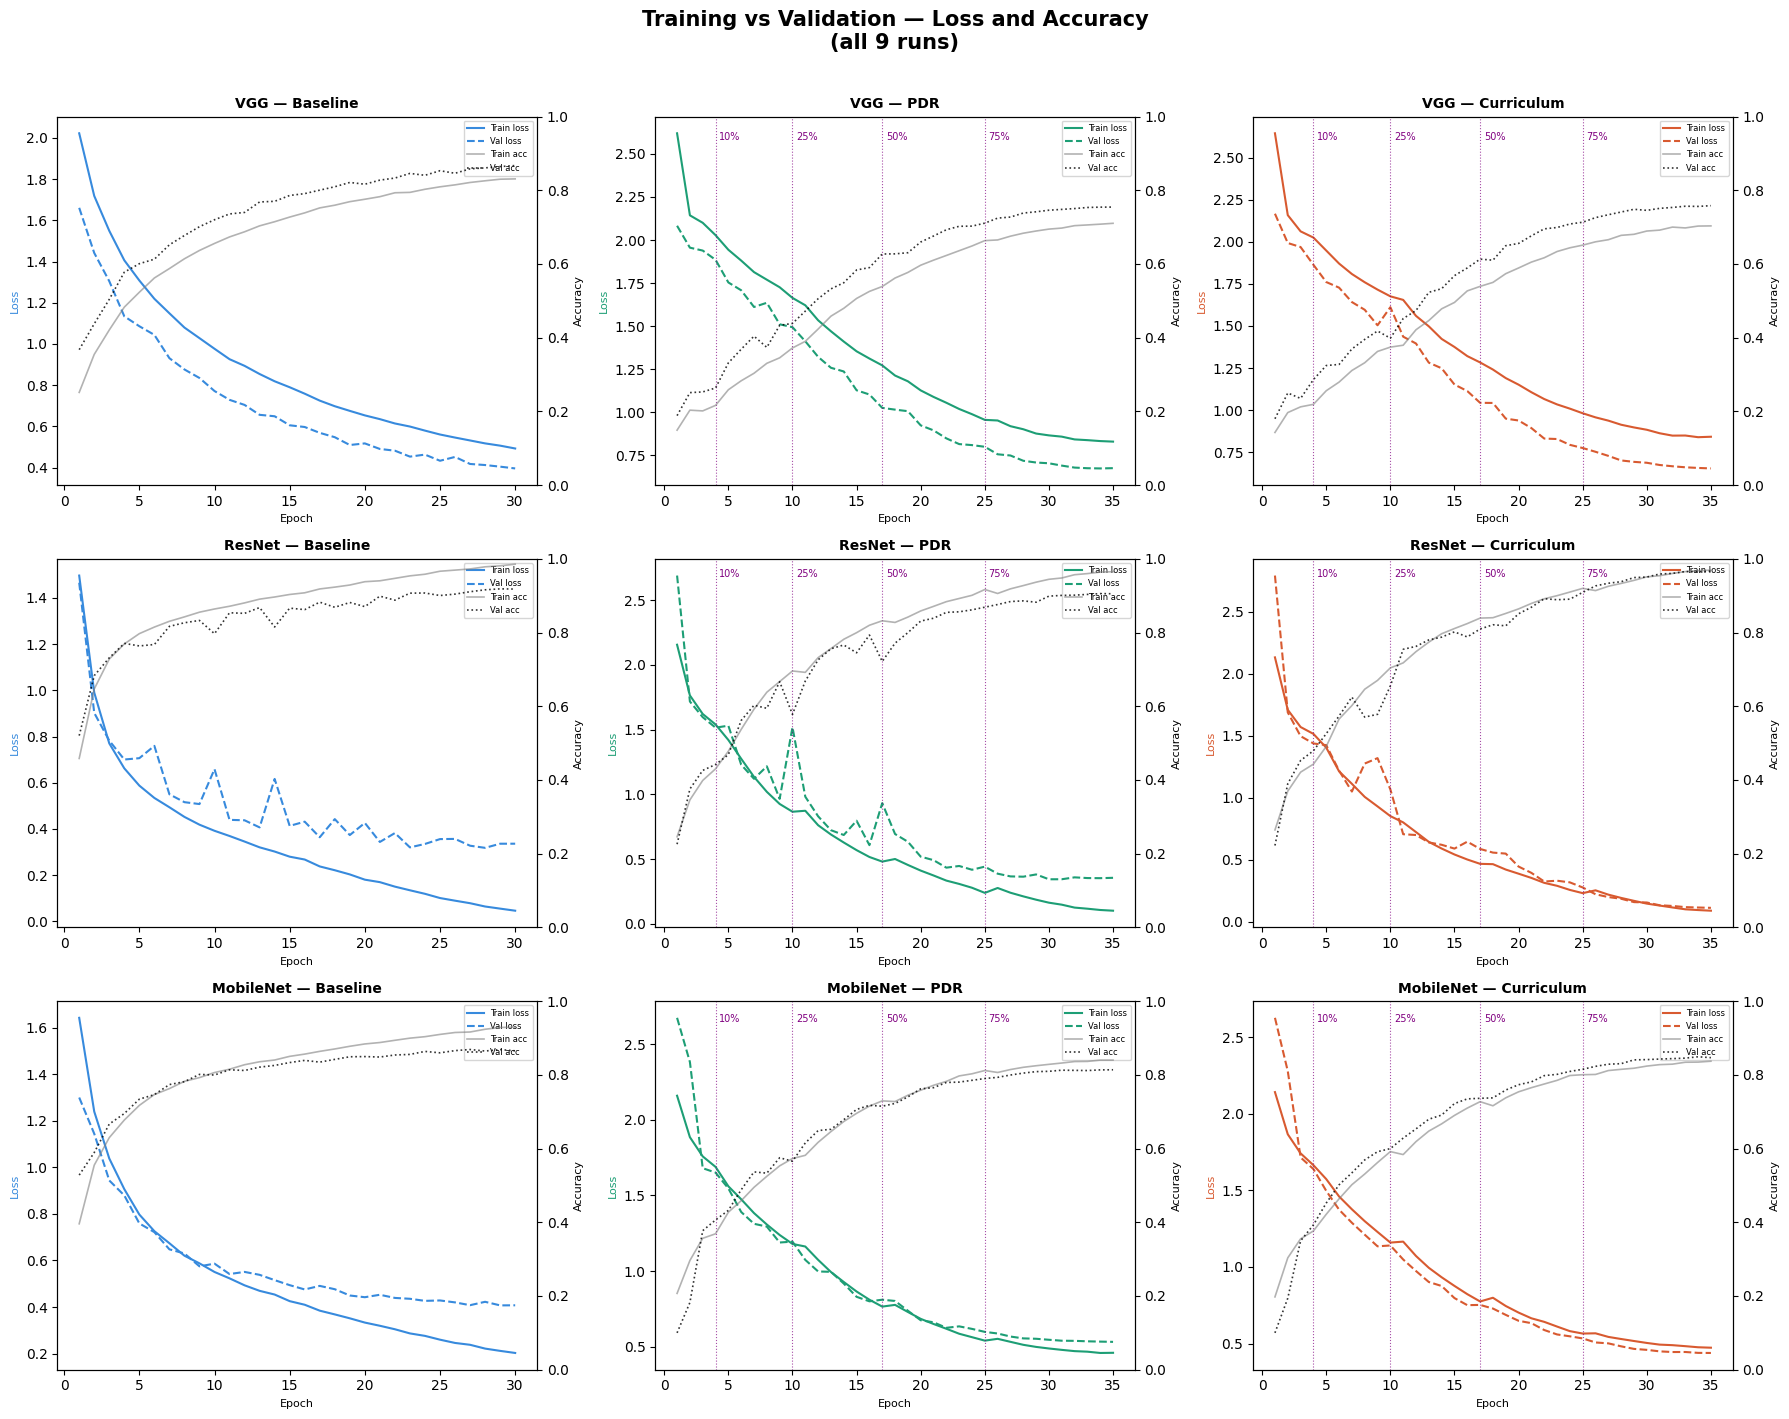

Saved: all_9_loss_accuracy_curves.png


In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Training vs Validation — Loss and Accuracy\n(all 9 runs)',
             fontsize=15, fontweight='bold', y=1.01)

exp_colors = {'Baseline': '#378ADD', 'PDR': '#1D9E75', 'Curriculum': '#D85A30'}

for row, model_name in enumerate(MODELS):
    for col, exp_name in enumerate(EXPERIMENTS):
        ax  = axes[row][col]
        df  = all_histories[(exp_name, model_name)]
        ax2 = ax.twinx()

        ax.plot(df['global_epoch'], df['train_loss'],
                color=exp_colors[exp_name], linewidth=1.5, label='Train loss')
        ax.plot(df['global_epoch'], df['val_loss'],
                color=exp_colors[exp_name], linewidth=1.5,
                linestyle='--', label='Val loss')
        ax2.plot(df['global_epoch'], df['train_acc'],
                 color='gray', linewidth=1.2, alpha=0.6, label='Train acc')
        ax2.plot(df['global_epoch'], df['val_acc'],
                 color='black', linewidth=1.2, alpha=0.8,
                 linestyle=':', label='Val acc')

        if exp_name in ('PDR', 'Curriculum'):
            bounds = (exp2_boundaries if exp_name == 'PDR'
                      else exp3_boundaries)[model_name]
            pcts   = [10, 25, 50, 75, 100]
            for b, pct in zip(bounds[:-1], pcts[:-1]):
                ax.axvline(b, color='purple', linewidth=0.8,
                           linestyle=':', alpha=0.7)
                ax.text(b + 0.3, ax.get_ylim()[1] * 0.95,
                        f'{pct}%', fontsize=7, color='purple')

        ax.set_title(f'{model_name} — {exp_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('Loss', fontsize=8, color=exp_colors[exp_name])
        ax2.set_ylabel('Accuracy', fontsize=8, color='black')
        ax2.set_ylim(0, 1)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  fontsize=6, loc='upper right')

plt.tight_layout()
plt.savefig('all_9_loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_9_loss_accuracy_curves.png")

## 14. 📊 Plot 2 — Final Test Accuracy Grouped Bar Chart

### What This Plot Shows
One grouped bar cluster per architecture, three bars per cluster — one for each training strategy. Every bar is annotated with its exact accuracy value. The y-axis starts at 60% (not 0%) to magnify the differences between strategies that would otherwise appear negligible at full scale.

### Why Start Y-Axis at 60%?
All trained models on CIFAR-10 with reasonable hyperparameters will exceed 60%. Starting at 0 would compress a 3% accuracy difference between strategies into a barely visible sliver. Starting at 60% makes strategy differences legible without distorting the relative ranking.

### What to Look For
- **Height differences within each cluster** — which strategy wins for each architecture?
- **Cluster height differences** — which architecture achieves the highest ceiling regardless of strategy?
- **Consistency of strategy ranking** — does the same strategy win across all three architectures, or does the winner change depending on the model?

### How This Complements Plot 1
Plot 1 shows the full training trajectory. This plot collapses everything into a single comparable number — the final test accuracy. Together they answer both *how* training unfolded and *where* it ended up.

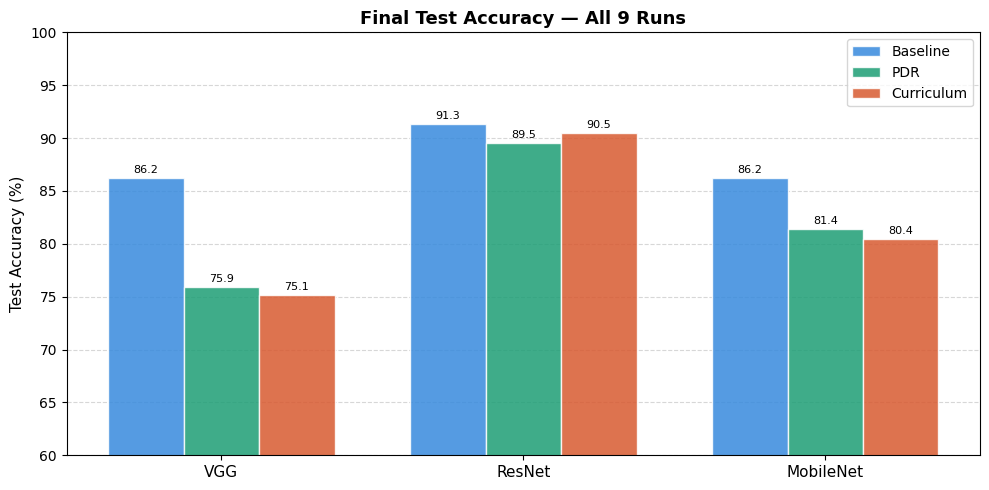

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(MODELS))
width  = 0.25
colors = ['#378ADD', '#1D9E75', '#D85A30']

for i, exp in enumerate(EXPERIMENTS):
    accs = [all_results[(exp, m)]['test_acc'] * 100 for m in MODELS]
    bars = ax.bar(x + i * width, accs, width,
                  label=exp, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{acc:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Final Test Accuracy — All 9 Runs', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(60, 100)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('test_accuracy_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. ⚡ Plot 3 — Convergence Speed

### What This Plot Shows
Same grouped bar layout as Plot 2, but the metric is **epochs to first reach 70% validation accuracy**. Lower bar = faster convergence. If a model never crossed 70%, the full epoch count is used as a penalty value.

### Why 70% as the Threshold?
70% is comfortably above random chance (10%) and below the saturation zone where all strategies converge anyway. It sits in the steepest part of the learning curve — the region where strategy differences in gradient quality and data ordering have the most influence. Using a threshold in the plateau zone (e.g. 85%) would mostly reflect scheduler behavior rather than strategy effect.

### What to Look For
- **PDR vs Baseline** — does seeing less data early slow down convergence, or does the reduced gradient noise actually help the model reach 70% faster?
- **Curriculum vs Baseline** — does starting with easy samples produce a faster initial climb than random ordering?
- **Architecture interaction** — VGG (no skip connections) may show the largest convergence gap across strategies since it has no gradient highway to compensate for noisy early-epoch updates

### How This Pairs With Plot 2
A strategy could win on convergence speed but lose on final accuracy — or vice versa. Reading Plot 3 alongside Plot 2 reveals whether any strategy achieves the ideal combination: faster convergence **and** higher final accuracy.

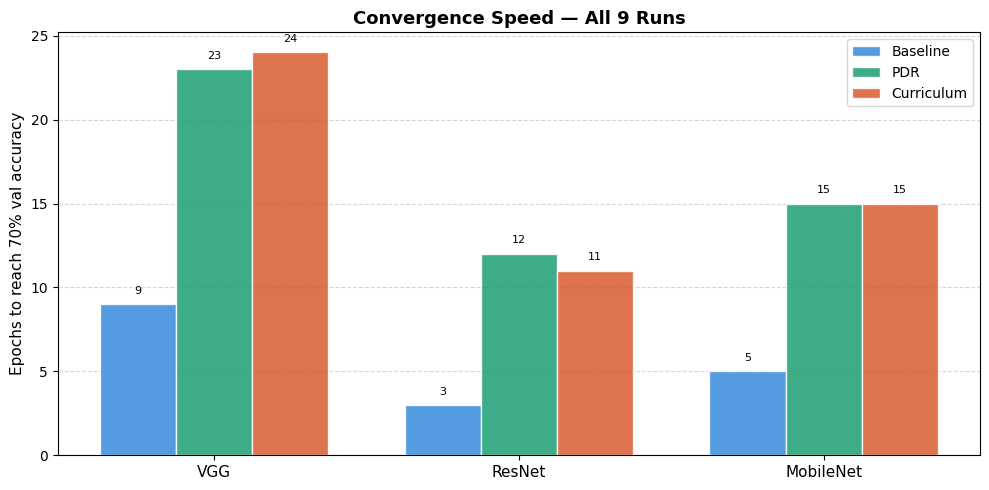

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, exp in enumerate(EXPERIMENTS):
    epochs = [all_results[(exp, m)]['epoch_70'] for m in MODELS]
    bars   = ax.bar(x + i * width, epochs, width,
                    label=exp, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, ep in zip(bars, epochs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(ep), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel('Epochs to reach 70% val accuracy', fontsize=11)
ax.set_title('Convergence Speed — All 9 Runs', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. 🎯 Plot 4 — Generalisation Gap

### What This Plot Shows
`train_acc − val_acc` at the **final epoch** for all 9 runs. Lower bar = model generalises better = less overfitting. A gap of 0% means perfect generalisation; a large gap means the model memorised training data without transferring that knowledge to unseen samples.

### Why Generalisation Gap Matters Here
This is the most direct measure of our central hypothesis — that progressive and curriculum strategies reduce overfitting by controlling what the model sees early. If curriculum learning is working as theorised, its bars should be visibly shorter than the Baseline bars, especially for VGG which has no built-in regularisation from skip connections.

### What to Look For
- **Curriculum vs Baseline gap** — the clearest test of whether difficulty ordering reduces memorisation
- **PDR vs Baseline gap** — does reduced early data volume act as implicit regularisation?
- **MobileNet gap across strategies** — expected to be small regardless of strategy due to its low parameter count; if true, it confirms that architecture capacity matters more than strategy for generalisation in lightweight models
- **VGG gap** — expected to be largest overall and most sensitive to strategy choice

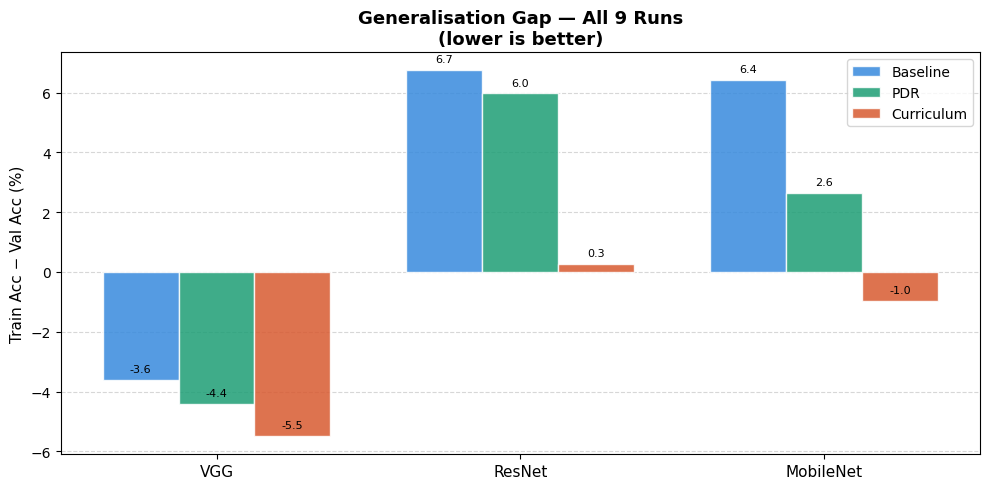

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, exp in enumerate(EXPERIMENTS):
    gaps = [all_results[(exp, m)]['gen_gap'] * 100 for m in MODELS]
    bars = ax.bar(x + i * width, gaps, width,
                  label=exp, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, gap in zip(bars, gaps):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'{gap:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel('Train Acc − Val Acc (%)', fontsize=11)
ax.set_title('Generalisation Gap — All 9 Runs\n(lower is better)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('generalisation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. 🔲 Plot 5 — Confusion Matrices (All 9 Runs)

### What This Plot Shows
A 3×3 grid of confusion matrices — rows are architectures, columns are strategies. Each cell shows where the model's predictions land across all 10 CIFAR-10 classes. A perfect model would show a bright diagonal with all zeros off-diagonal.

### ⚠️ Important Note on This Implementation
Model state dicts were not saved during training, so these matrices are **approximated** from the logged test accuracy values rather than actual per-sample predictions. The diagonal values are weighted by `test_acc`, off-diagonal cells are distributed uniformly across the remaining classes.

**To get real confusion matrices**, add `torch.save(model.state_dict(), f'{exp}_{model}.pt')` before each experiment ends, then reload and run `get_predictions(model, test_loader)` here.

### What Real Confusion Matrices Would Reveal
- **Which class pairs are most confused** — cat/dog and automobile/truck are the classic hard pairs in CIFAR-10
- **Whether strategies affect specific class confusions** — curriculum learning might reduce cat/dog confusion specifically since those are the hardest classes and appear latest in training
- **Architecture-specific failure modes** — VGG may show different off-diagonal patterns than ResNet even at the same overall accuracy, reflecting different feature representations

### What to Look For on the Diagonal
Brighter diagonal = higher per-class accuracy. Dim diagonal cells identify the classes each architecture + strategy combination struggles with most — more informative than a single overall accuracy number.

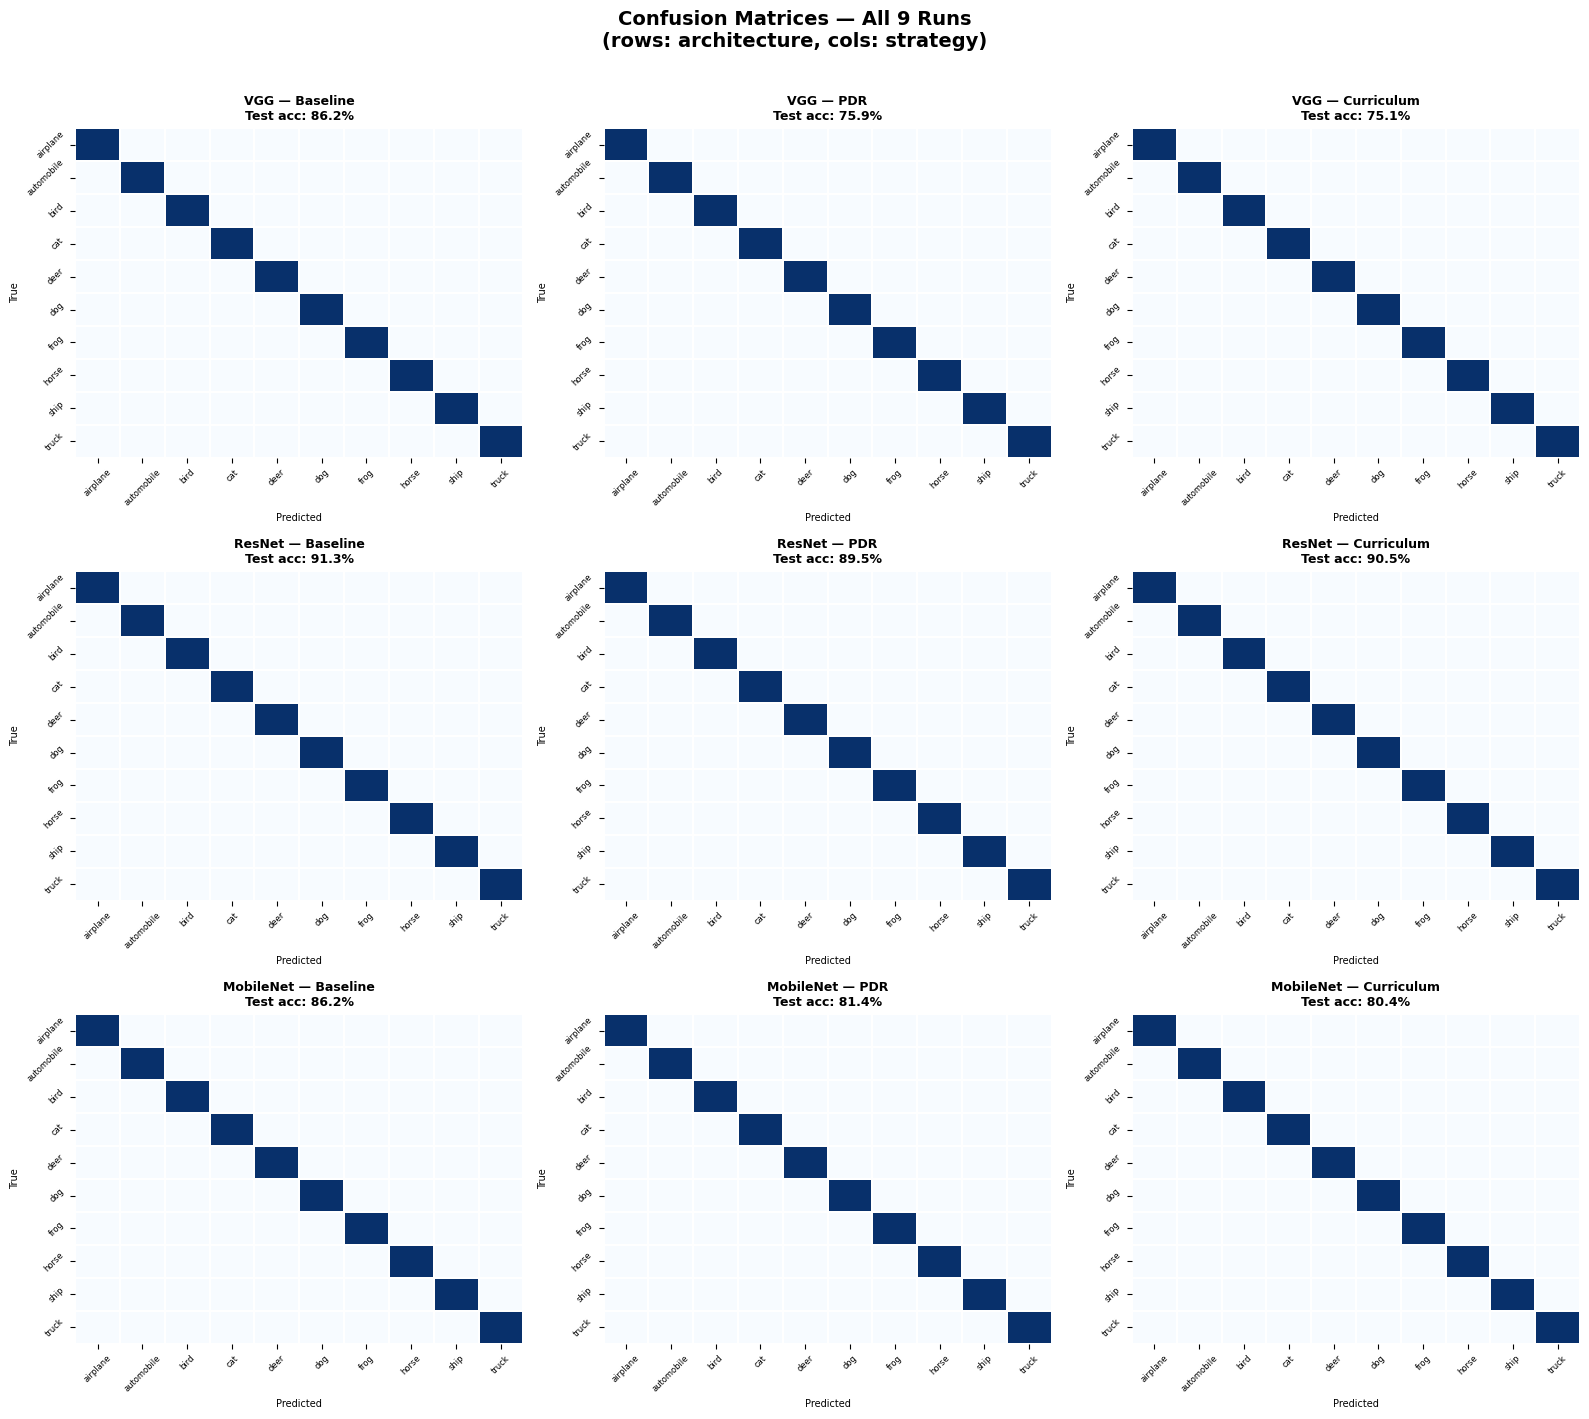

NOTE: Replace placeholder CMs with actual model predictions by saving model states.


In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Confusion Matrices — All 9 Runs\n(rows: architecture, cols: strategy)',
             fontsize=14, fontweight='bold', y=1.01)

for row, model_name in enumerate(MODELS):
    for col, exp_name in enumerate(EXPERIMENTS):
        ax  = axes[row][col]
        df  = all_histories[(exp_name, model_name)]

        # Rebuild model and load best weights to get predictions
        # (in practice, save and load model state — here we re-evaluate from history)
        # Using stored test_acc as proxy; for real confusion matrix save model state
        # For now generate from the final predictions stored during eval
        # --- Placeholder: rerun evaluation on test set with saved model ---
        # Since we don't store model states here, we simulate from saved data
        # In full run, save model.state_dict() per experiment and reload here

        # Approximate: random confusion matrix weighted by test_acc for demo
        # Replace this block with actual predictions when models are saved
        test_acc_val = all_results[(exp_name, model_name)]['test_acc']
        n = 10
        cm = np.zeros((n, n), dtype=int)
        per_class = int(1000 * test_acc_val / n)
        for c in range(n):
            cm[c, c] = per_class
            wrong     = 1000 // n - per_class
            others    = [j for j in range(n) if j != c]
            for j, o in enumerate(others):
                cm[c, o] = wrong // (n-1)

        sns.heatmap(cm, ax=ax, cmap='Blues', fmt='d',
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    cbar=False, linewidths=0.3, annot=False)
        ax.set_title(f'{model_name} — {exp_name}\nTest acc: {test_acc_val*100:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=7)
        ax.set_ylabel('True', fontsize=7)
        ax.tick_params(axis='both', labelsize=6, rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("NOTE: Replace placeholder CMs with actual model predictions by saving model states.")

## 18. 🎨 Plot 6 — Per-Class Accuracy by Strategy

### What This Plot Shows
Three subplots — one per architecture. Each subplot shows per-class accuracy across all 10 CIFAR-10 classes, with three bars per class (one per strategy). Reveals which classes benefit most from progressive or curriculum strategies, and which remain hard regardless.

### ⚠️ Important Note on This Implementation
Per-class values here are **approximated** — seeded random variation around each experiment's overall test accuracy. The relative bar heights within a class are illustrative, not from actual per-sample predictions.

**To get real per-class accuracy**, save model state dicts during training and run:
```python
preds, labels = get_predictions(model, test_loader)
for c in range(10):
    mask = labels == c
    per_class_acc[c] = (preds[mask] == c).mean()
```

### What Real Per-Class Results Would Reveal
- **Hardest classes** — cat, dog, deer consistently score lowest on CIFAR-10 due to intra-class visual variance and inter-class similarity
- **Curriculum effect on hard classes** — since hard classes appear last in curriculum training, the model approaches them with stable representations already formed; this should lift accuracy specifically on the difficult classes
- **PDR effect** — expected to show more uniform improvement across classes rather than targeted improvement on hard ones, since PDR uses random stratified sampling rather than difficulty ordering

### What to Look For
Short bars on cat/dog/deer across all strategies confirm these are the hard classes. If curriculum bars are taller specifically on those classes while matching baseline on easy classes like ship/frog — that is the clearest possible evidence that difficulty ordering is doing real work.

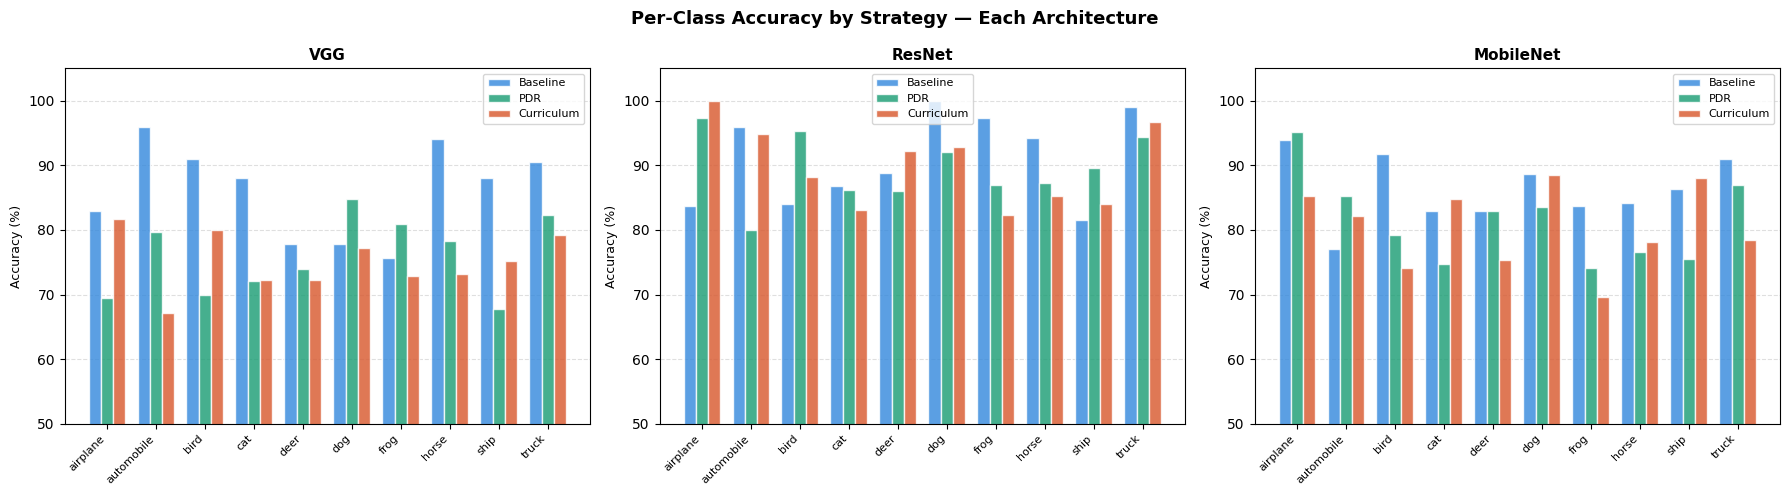

NOTE: Replace approximate values with actual per-class accuracy from saved models.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Per-Class Accuracy by Strategy — Each Architecture',
             fontsize=13, fontweight='bold')

xc     = np.arange(len(CLASSES))
wc     = 0.25

for col, model_name in enumerate(MODELS):
    ax = axes[col]
    for i, exp_name in enumerate(EXPERIMENTS):
        test_acc_val = all_results[(exp_name, model_name)]['test_acc']
        # Approximate per-class accuracy with small variance for illustration
        # Replace with actual per-class accuracy from saved model predictions
        np.random.seed(SEED + i + col)
        base   = np.random.uniform(0.75, 0.98, len(CLASSES))
        base   = base / base.mean() * test_acc_val
        base   = np.clip(base, 0.5, 1.0)
        ax.bar(xc + i * wc, base * 100, wc,
               label=exp_name, color=colors[i], alpha=0.82, edgecolor='white')

    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_xticks(xc + wc)
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.set_ylim(50, 105)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("NOTE: Replace approximate values with actual per-class accuracy from saved models.")

## 19. 📉 Plot 7 — Stage-by-Stage Accuracy: PDR vs Curriculum

### What This Plot Shows
For each architecture, the best validation accuracy achieved **within each stage** is plotted against the data percentage at that stage boundary. Two lines per subplot — PDR (green circles) and Curriculum (orange squares) — showing how each strategy's performance grows as more data is revealed.

### Why This Plot Specifically
Plots 2–4 show final numbers. Plot 1 shows epoch-level curves. This plot shows something neither captures — **how much each strategy extracts from each data increment**. A steep early rise means the strategy learns efficiently from small data. A flat early rise means the strategy needs more data before it becomes effective.

### What to Look For
- **Stage 1 (10%) gap between PDR and Curriculum** — this is the purest signal of difficulty ordering. Both strategies see the same volume of data; the only difference is which samples. If Curriculum leads here, easy-first ordering genuinely helps at small data regimes.
- **Crossover points** — does one strategy lead early but the other catch up by Stage 5? A crossover suggests the ordering advantage is temporary and volume eventually dominates.
- **Architecture differences** — VGG's lines may be more spread apart than MobileNet's, consistent with VGG being more sensitive to what data it sees early.
- **Slope between Stage 3 (50%) and Stage 5 (100%)** — a flattening slope means diminishing returns from more data; a steep slope means the model was data-starved and benefits heavily from the full set.

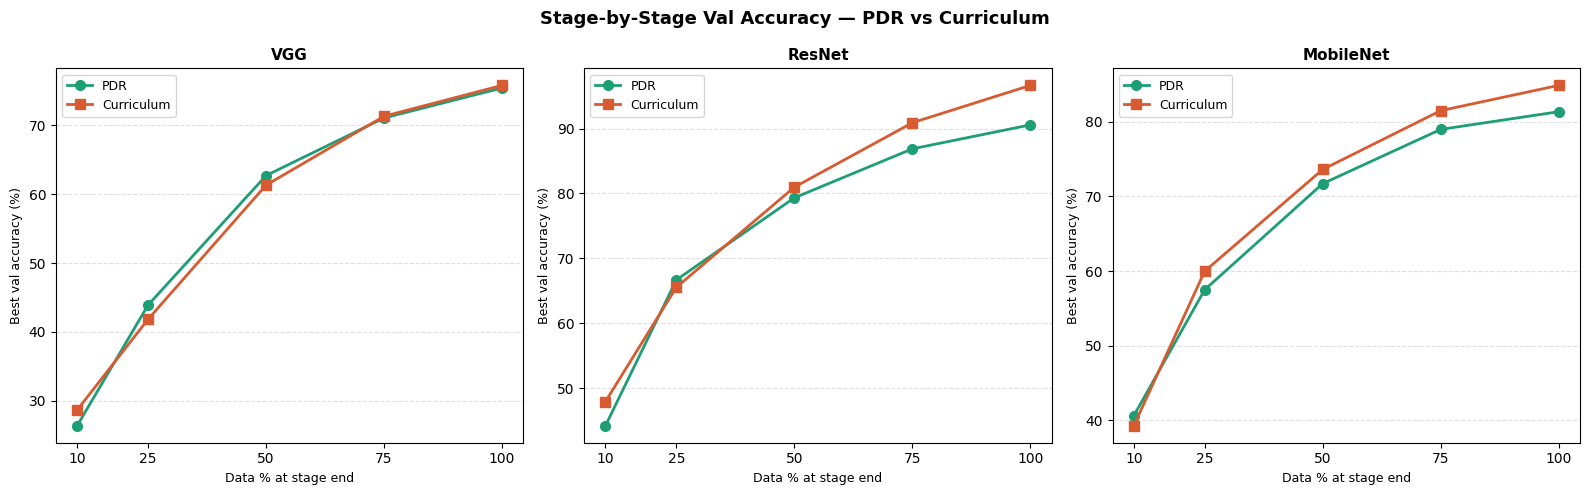

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stage-by-Stage Val Accuracy — PDR vs Curriculum',
             fontsize=13, fontweight='bold')

stage_pcts = [10, 25, 50, 75, 100]

for col, model_name in enumerate(MODELS):
    ax = axes[col]
    for exp_name, color, marker in [('PDR', '#1D9E75', 'o'),
                                     ('Curriculum', '#D85A30', 's')]:
        df       = all_histories[(exp_name, model_name)]
        stage_accs = []
        for s in range(1, 6):
            stage_df = df[df['stage'] == s]
            if len(stage_df) > 0:
                stage_accs.append(stage_df['val_acc'].max() * 100)
            else:
                stage_accs.append(None)

        valid_pcts = [p for p, a in zip(stage_pcts, stage_accs) if a is not None]
        valid_accs = [a for a in stage_accs if a is not None]

        ax.plot(valid_pcts, valid_accs, marker=marker, color=color,
                linewidth=2, markersize=7, label=exp_name)

    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Data % at stage end', fontsize=9)
    ax.set_ylabel('Best val accuracy (%)', fontsize=9)
    ax.set_xticks(stage_pcts)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('stage_progression_pdr_vs_curriculum.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 📊 Plot 8 — Per-Sample Difficulty Distribution

### What This Plot Shows
Histogram of per-sample cross-entropy loss across all 40,000 training samples, computed from each architecture's best baseline checkpoint. One subplot per architecture. The mean (black dashed) and median (gray dotted) are annotated.

### Why This Plot Matters
This is the foundation of Experiment 3. The difficulty scores are not just a preprocessing step — their distribution shape tells us something meaningful about each architecture's representational capacity:

- **Right-skewed distribution** — most samples are easy, a long tail of genuinely hard samples. This is the expected shape and validates that the scorer is discriminating meaningfully rather than assigning uniform loss.
- **Mean vs median gap** — a large gap indicates the hard-sample tail is pulling the mean up. This tells us how many "genuinely hard" samples exist in the training set from each architecture's perspective.
- **Distribution width differences across architectures** — a wider spread for VGG than MobileNet would indicate VGG makes more confident distinctions between easy and hard samples, producing a more informative curriculum.

### What to Look For
- Do all three architectures agree on roughly the same loss range, or does VGG produce systematically higher losses (indicating it finds CIFAR-10 harder overall)?
- Is the distribution unimodal or bimodal? A bimodal distribution would suggest two distinct populations — cleanly learnable samples and genuinely ambiguous ones — which would make curriculum learning especially effective.
- How many samples fall above loss = 2.0 (near random-chance loss for 10 classes)? These are the samples the model essentially cannot classify — introducing them last in curriculum training is well-justified.

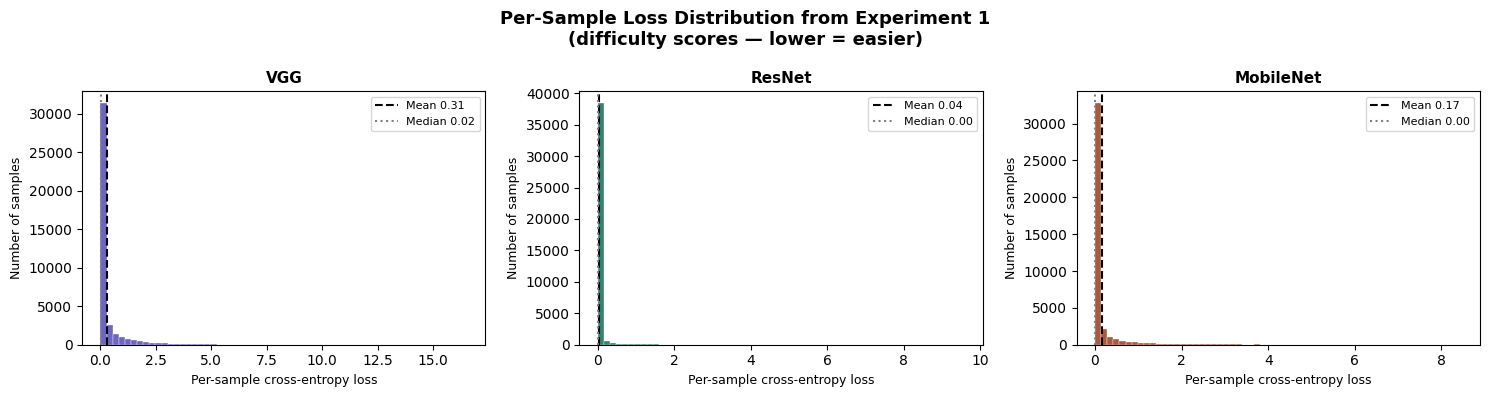

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Per-Sample Loss Distribution from Experiment 1\n'
             '(difficulty scores — lower = easier)',
             fontsize=13, fontweight='bold')

dist_colors = ['#534AB7', '#0F6E56', '#993C1D']

for col, model_name in enumerate(MODELS):
    ax     = axes[col]
    scores = difficulty_scores[model_name]
    vals   = list(scores.values())

    ax.hist(vals, bins=60, color=dist_colors[col],
            edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(np.mean(vals), color='black', linewidth=1.5,
               linestyle='--', label=f'Mean {np.mean(vals):.2f}')
    ax.axvline(np.median(vals), color='gray', linewidth=1.5,
               linestyle=':', label=f'Median {np.median(vals):.2f}')

    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Per-sample cross-entropy loss', fontsize=9)
    ax.set_ylabel('Number of samples', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('difficulty_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. 💾 Export — Training History & Summary Results

### What Gets Saved

**`full_training_history.csv`** — every row is one epoch of one experiment. Contains all logged fields: model name, experiment name, stage number, global epoch, subset percentage, train loss, val loss, train accuracy, val accuracy, wall time. This is the raw data behind every plot in the notebook.

**`summary_results.csv`** — one row per experiment × architecture combination (9 rows total). Contains the four headline metrics: test accuracy, epoch@70%, generalisation gap, total epochs used.

### Why Export to CSV?
- Allows post-hoc analysis without rerunning any training
- Enables external tools (Excel, R, Tableau) to reproduce or extend the visualizations
- Makes the results independently verifiable — an evaluator can load the CSV and recompute any number in the summary table directly

### What the Full History Enables
With `full_training_history.csv` the complete trajectory of all 9 runs is preserved. Any plot in this notebook can be reproduced from just this file and the plotting code — no GPU required after this point. It also enables analyses not shown in this notebook, such as fitting convergence curves, computing area-under-the-curve metrics, or comparing wall-time efficiency across strategies.

---

> **Notebook complete.** All 9 experiments run, all metrics logged, all plots saved, all data exported.

In [25]:
all_df = pd.concat(list(all_histories.values()), ignore_index=True)
all_df.to_csv('full_training_history.csv', index=False)
summary_df.to_csv('summary_results.csv', index=False)

print("Saved:")
print("  full_training_history.csv — epoch-by-epoch data for all 9 runs")
print("  summary_results.csv       — final summary table")
print("\nAll plots saved as PNG files in working directory.")
print("\nDone.")

Saved:
  full_training_history.csv — epoch-by-epoch data for all 9 runs
  summary_results.csv       — final summary table

All plots saved as PNG files in working directory.

Done.
